**Описание проекта: Промышленность**

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Наша задача — построить модель, которая будет её предсказывать. 
Заказчик хочет использовать разработанную модель для имитации технологического процесса. 




**Описание этапа обработки**

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены в крышке ковша. 

Из сплава выводится сера (этот процесс — десульфурация), добавлением примесей корректируется химический состав и отбираются пробы. Сталь легируют — изменяют её состав — подавая куски сплава из бункера для сыпучих материалов или проволоку через специальный трайб-аппарат (от англ. tribe — «масса»).

Перед тем как первый раз ввести легирующие добавки, измеряют температуру стали и производят её химический анализ. Потом температуру на несколько минут повышают, добавляют легирующие материалы и продувают сплав инертным газом. Затем его перемешивают и снова проводят измерения. Такой цикл повторяется до достижения целевого химического состава и оптимальной температуры плавки.
Тогда расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (от англ. slab — «плита»).

**Описание данных**


Данные состоят из нескольких файлов, полученных из разных источников:

/datasets/data_arc_new.csv — данные об электродах:

key — номер партии;
Начало нагрева дугой — время начала нагрева;
Конец нагрева дугой — время окончания нагрева;
Активная мощность — значение активной мощности;
Реактивная мощность — значение реактивной мощности.

/datasets/data_bulk_new.csv — данные о подаче сыпучих материалов (объём):

key — номер партии;
Bulk 1 … Bulk 15 — объём подаваемого материала.

/datasets/data_bulk_time_new.csv — данные о подаче сыпучих материалов (время):

key — номер партии;
Bulk 1 … Bulk 15 — время подачи материала.

/datasets/data_gas_new.csv — данные о продувке сплава газом:

key — номер партии;
Газ 1 — объём подаваемого газа.

/datasets/data_temp_new.csv — результаты измерения температуры:

key — номер партии;
Время замера — время замера;
Температура — значение температуры.

/datasets/data_wire_new.csv — данные о проволочных материалах (объём):

key — номер партии;
Wire 1 … Wire 15 — объём подаваемых проволочных материалов.

/datasets/data_wire_time_new.csv — данные о проволочных материалах (время).

key — номер партии;
Wire 1 … Wire 15 — время подачи проволочных материалов.

Во всех файлах столбец key содержит номер партии. В файлах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

**План работы**

1. Загрузка данных

     Загрузим данные и выполним их первичный осмотр.


2. Исследовательский анализ и предобработка данных

     Выполним исследовательский анализ каждого датафрейма и при необходимости выполним предобработку. Сделаем выводы об имеющихся признаках: понадобятся ли они для обучения моделей.


3. Объединение данных

     Объединим выбранные нами признаки в один датафрейм по ключу.


4. Исследовательский анализ и предобработка данных объединённого датафрейма

     Выполним исследовательский анализ объединённого датафрейма, визуализируем распределения признаков и при необходимости выполним предобработку. Проведем корреляционный анализ. Мы можем использовать не только имеющиеся признаки, но и генерировать новые.


5. Подготовка данных

     Выполним подготовку данных для обучения модели. Разделим данные на две выборки, при масштабировании и кодировании учтем особенности данных и моделей.
 

6. Обучение моделей машинного обучения

     Обучим как минимум две(три) модели. Хотя бы для одной из них подберем как минимум два гиперпараметра.


7. Выбор лучшей модели

     Выберем лучшую модель и проверим её качество на тестовой выборке.


8. Общий вывод и рекомендации заказчику
 
     Сделаем общий вывод о проделанной работе: опишем основные этапы работы, полученные результаты и дадим рекомендации для бизнеса.

# Шаг 1: Загрузка данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [2]:
# Создадим функцию вывода информации о датафрейме
def desc_dat(df, name="DataFrame"):
    try:
        
        print(f"Название: {name}\n")
        duplicates = df.duplicated().sum()
        print(f"Количество дубликатов: {duplicates}\n")
        missing_values = df.isna().sum()
        print(f"Количество пропусков:\n{missing_values}\n")
        print(f'Размер: {df.shape}\n')
        display(df.head(10))
        display(df.describe())
    except Exception as e:
        print(f"Ошибка при обработке {name}: {e}")

In [ ]:
try:
    # Пробуем загрузить из локального пути
    data_arc_new = pd.read_csv('/datasets/data_arc_new.csv', parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
    print("Данные загружены из локального файла.")
except FileNotFoundError:
    # Если локальный файл не найден, загружаем из URL
    data_arc_new = pd.read_csv('https://code.s3.yandex.net/datasets/data_arc_new.csv', parse_dates=['Начало нагрева дугой', 'Конец нагрева дугой'])
    print("Данные загружены по URL.")

In [4]:
desc_dat(data_arc_new, "data_arc_new.csv" )

Название: data_arc_new.csv

Количество дубликатов: 0

Количество пропусков:
key                     0
Начало нагрева дугой    0
Конец нагрева дугой     0
Активная мощность       0
Реактивная мощность     0
dtype: int64

Размер: (14876, 5)



,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691
5,2,2019-05-03 11:34:14,2019-05-03 11:36:31,0.381124,0.220351
6,2,2019-05-03 11:38:50,2019-05-03 11:44:28,0.261665,0.205527
7,2,2019-05-03 11:46:19,2019-05-03 11:48:25,0.710297,0.484962
8,2,2019-05-03 11:49:48,2019-05-03 11:53:18,0.786322,0.542517
9,3,2019-05-03 12:06:54,2019-05-03 12:11:34,1.101678,0.820856


,key,Активная мощность,Реактивная мощность
count,14876.000000,14876.000000,14876.000000
mean,1615.220422,0.662752,0.438986
std,934.571502,0.258885,5.873485
min,1.000000,0.223120,-715.479924
25%,806.000000,0.467115,0.337175
50%,1617.000000,0.599587,0.441639
75%,2429.000000,0.830070,0.608201
max,3241.000000,1.463773,1.270284


In [ ]:
try:
    data_bulk_new = pd.read_csv('/datasets/data_bulk_new.csv')
except FileNotFoundError:
    data_bulk_new = pd.read_csv('https://code.s3.yandex.net/datasets/data_bulk_new.csv')

In [6]:
desc_dat(data_bulk_new, "data_bulk_new.csv" )

Название: data_bulk_new.csv

Количество дубликатов: 0

Количество пропусков:
key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881
dtype: int64

Размер: (3129, 16)



,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0
5,6,NaN,NaN,NaN,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,NaN,201.0,154.0
6,7,NaN,NaN,NaN,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,NaN,152.0,154.0
7,8,NaN,NaN,NaN,99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0,NaN,252.0,153.0
8,9,NaN,NaN,NaN,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0,NaN,99.0,203.0
9,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,102.0,204.0


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


In [ ]:
try:
    data_bulk_time_new = pd.read_csv(
        '/datasets/data_bulk_time_new.csv',
        parse_dates=['Bulk 1', 'Bulk 2', 'Bulk 3', 'Bulk 4', 'Bulk 5',
                     'Bulk 6', 'Bulk 7', 'Bulk 8', 'Bulk 9', 'Bulk 10',
                     'Bulk 11', 'Bulk 12', 'Bulk 13', 'Bulk 14', 'Bulk 15']
    )
except FileNotFoundError:
    data_bulk_time_new = pd.read_csv(
        'https://code.s3.yandex.net/datasets/data_bulk_time_new.csv',
        parse_dates=['Bulk 1', 'Bulk 2', 'Bulk 3', 'Bulk 4', 'Bulk 5',
                     'Bulk 6', 'Bulk 7', 'Bulk 8', 'Bulk 9', 'Bulk 10',
                     'Bulk 11', 'Bulk 12', 'Bulk 13', 'Bulk 14', 'Bulk 15']
    )

In [8]:
desc_dat(data_bulk_time_new, "data_bulk_time_new.csv" )

Название: data_bulk_time_new.csv

Количество дубликатов: 0

Количество пропусков:
key           0
Bulk 1     2877
Bulk 2     3107
Bulk 3     1831
Bulk 4     2115
Bulk 5     3052
Bulk 6     2553
Bulk 7     3104
Bulk 8     3128
Bulk 9     3110
Bulk 10    2953
Bulk 11    2952
Bulk 12     679
Bulk 13    3111
Bulk 14     323
Bulk 15     881
dtype: int64

Размер: (3129, 16)



,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaT,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,NaT,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,2019-05-03 13:34:12,2019-05-03 13:30:47
5,6,NaT,NaT,NaT,2019-05-03 13:57:27,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:48:52,NaT,2019-05-03 14:09:42,2019-05-03 14:03:15
6,7,NaT,NaT,NaT,2019-05-03 14:18:58,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 14:41:26,NaT,2019-05-03 14:30:50,2019-05-03 14:27:16
7,8,NaT,NaT,NaT,2019-05-03 15:17:58,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 15:17:58,NaT,2019-05-03 15:13:18,2019-05-03 15:05:33
8,9,NaT,NaT,NaT,2019-05-03 16:03:08,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 16:03:08,NaT,2019-05-03 16:00:16,2019-05-03 15:52:39
9,10,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 16:38:11,NaT,2019-05-03 16:34:24,2019-05-03 16:29:56


,key
count,3129.000000
mean,1624.383509
std,933.337642
min,1.000000
25%,816.000000
50%,1622.000000
75%,2431.000000
max,3241.000000


In [ ]:
try:
    data_gas_new = pd.read_csv('/datasets/data_gas_new.csv')
except FileNotFoundError:
    data_gas_new = pd.read_csv('https://code.s3.yandex.net/datasets/data_gas_new.csv')

In [10]:
desc_dat(data_gas_new, "data_gas_new.csv" )

Название: data_gas_new.csv

Количество дубликатов: 0

Количество пропусков:
key      0
Газ 1    0
dtype: int64

Размер: (3239, 2)



,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692
5,6,11.273392
6,7,9.836267
7,8,15.171553
8,9,8.216623
9,10,6.529891


,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


In [ ]:
try:
    data_temp_new = pd.read_csv('/datasets/data_temp_new.csv', parse_dates=['Время замера'])
except FileNotFoundError:
    data_temp_new = pd.read_csv('https://code.s3.yandex.net/datasets/data_temp_new.csv', parse_dates=['Время замера'])

In [12]:
desc_dat(data_temp_new, "data_temp_new.csv" )

Название: data_temp_new.csv

Количество дубликатов: 0

Количество пропусков:
key                0
Время замера       0
Температура     3427
dtype: int64

Размер: (18092, 3)



,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0
5,1,2019-05-03 11:30:38,1613.0
6,2,2019-05-03 11:34:04,1581.0
7,2,2019-05-03 11:38:40,1577.0
8,2,2019-05-03 11:46:09,1589.0
9,2,2019-05-03 11:49:38,1604.0


,key,Температура
count,18092.000000,14665.000000
mean,1616.460977,1590.722741
std,934.641385,20.394381
min,1.000000,1191.000000
25%,807.750000,1580.000000
50%,1618.000000,1590.000000
75%,2429.000000,1599.000000
max,3241.000000,1705.000000


Много пропусков значений температуры, а это важный для нас параметр, будем учитывать.

In [ ]:
try:
    data_wire_new = pd.read_csv('/datasets/data_wire_new.csv')
except FileNotFoundError:
    data_wire_new = pd.read_csv('https://code.s3.yandex.net/datasets/data_wire_new.csv')

In [14]:
desc_dat(data_wire_new, "data_wire_new.csv" )

Название: data_wire_new.csv

Количество дубликатов: 0

Количество пропусков:
key          0
Wire 1      26
Wire 2    2002
Wire 3    3018
Wire 4    3067
Wire 5    3080
Wire 6    3008
Wire 7    3070
Wire 8    3062
Wire 9    3052
dtype: int64

Размер: (3081, 10)



,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.114560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,99.109917,9.114560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,98.061600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,155.282394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,113.393279,9.143681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,81.244796,12.376000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


In [ ]:
try:
    data_wire_time_new = pd.read_csv(
        '/datasets/data_wire_time_new.csv',
        parse_dates=['Wire 1', 'Wire 2', 'Wire 3', 'Wire 4', 'Wire 5', 
                     'Wire 6', 'Wire 7', 'Wire 8', 'Wire 9']
    )
except FileNotFoundError:
    data_wire_time_new = pd.read_csv(
        'https://code.s3.yandex.net/datasets/data_wire_time_new.csv',
        parse_dates=['Wire 1', 'Wire 2', 'Wire 3', 'Wire 4', 'Wire 5', 
                     'Wire 6', 'Wire 7', 'Wire 8', 'Wire 9']
    )

In [16]:
desc_dat(data_wire_time_new, "data_wire_time_new.csv" )

Название: data_wire_time_new.csv

Количество дубликатов: 0

Количество пропусков:
key          0
Wire 1      26
Wire 2    2002
Wire 3    3018
Wire 4    3067
Wire 5    3080
Wire 6    3008
Wire 7    3070
Wire 8    3062
Wire 9    3052
dtype: int64

Размер: (3081, 10)



,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
1,2,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,3,2019-05-03 12:11:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
3,4,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT
5,6,2019-05-03 13:57:27,2019-05-03 13:48:52,NaT,NaT,NaT,NaT,NaT,NaT,NaT
6,7,2019-05-03 14:18:58,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
7,8,2019-05-03 15:01:30,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
8,9,2019-05-03 15:45:44,2019-05-03 15:39:37,NaT,NaT,NaT,NaT,NaT,NaT,NaT
9,10,2019-05-03 16:27:00,2019-05-03 16:22:36,NaT,NaT,NaT,NaT,NaT,NaT,NaT


,key
count,3081.000000
mean,1623.426485
std,932.996726
min,1.000000
25%,823.000000
50%,1619.000000
75%,2434.000000
max,3241.000000


Загрузили данные. Данные в нормальном состоянии. В некоторых датафреймах много пропусков, скорее всего это значит, что действие не производилось и можно заменить пропуски на 0. При загрузке столбцы с датами прочитали сразу как формат datetime.

# Шаг 2: Исследовательский анализ и предобработка данных

In [17]:
# Создадим функцию которая будет строить графики для интересующего нас столбца в нужном датафрейме и выводить информацию о нём
def hist_func(df,col):
    fig, axs = plt.subplots(ncols=2,figsize=(16,8))
    sns.set(font_scale=1.10)
    histplot = sns.histplot(df[col],ax=axs[0], color='Purple', bins=50).set_title(f'Гистограмма распределения {col}',fontsize=20);
    sns.boxplot(df[col], ax=axs[1]).set_title(f'Диаграмма размаха {col}',fontsize=20); 
    
    print(df[col].describe()) 

In [18]:
# Приведём к единому стилю название столбцов в data_arc_new
data_arc_new.columns = ['key', 'start_heating','end_heating', 'active_power', 'reactive_power']
data_arc_new.columns

Index(['key', 'start_heating', 'end_heating', 'active_power',
       'reactive_power'],
      dtype='object')

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


count    14876.000000
mean         0.662752
std          0.258885
min          0.223120
25%          0.467115
50%          0.599587
75%          0.830070
max          1.463773
Name: active_power, dtype: float64


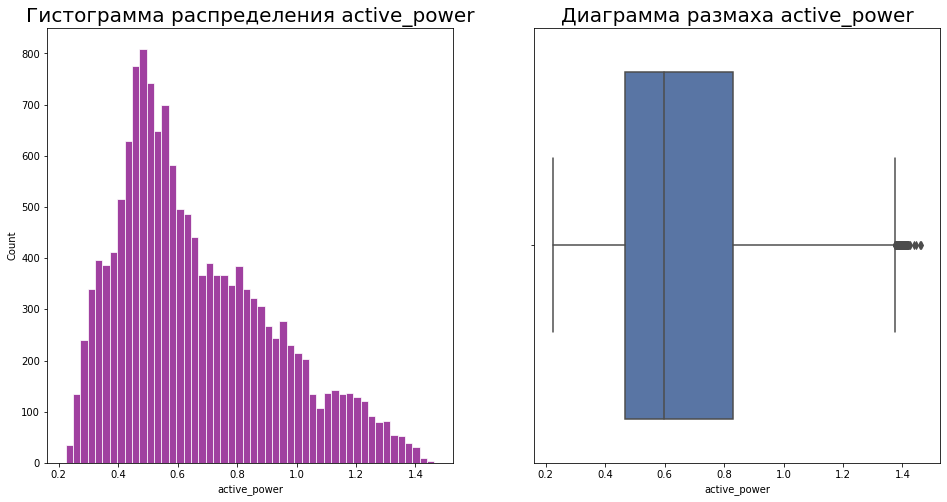

In [19]:
# Построим графики с помощью функции
hist_func(data_arc_new,'active_power')

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


count    14876.00
mean         0.44
std          5.87
min       -715.48
25%          0.34
50%          0.44
75%          0.61
max          1.27
Name: reactive_power, dtype: float64


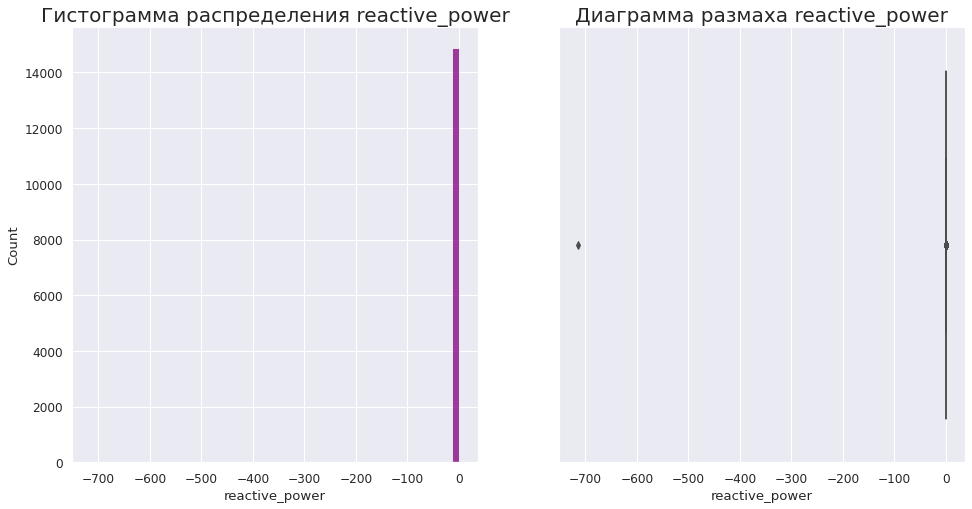

In [96]:
hist_func(data_arc_new,'reactive_power')

Здесь есть выброс, т.к. он всего один и значение и с положительным знаком будет выбросом, поэтому ничего с ним сделать нельзя кроме как удалить.

In [20]:
data_arc_new = data_arc_new.query('reactive_power > 0')

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


count    14875.000000
mean         0.487115
std          0.197612
min          0.153777
25%          0.337190
50%          0.441665
75%          0.608223
max          1.270284
Name: reactive_power, dtype: float64


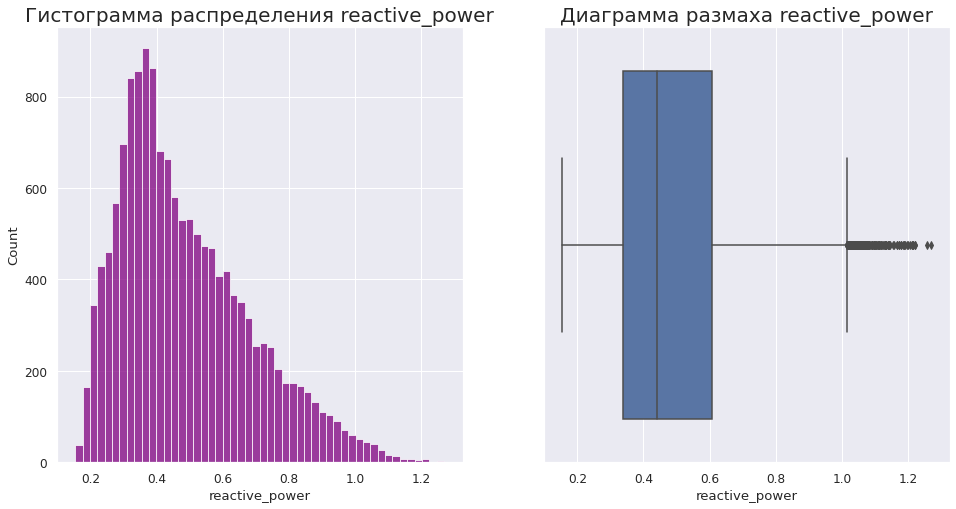

In [21]:
hist_func(data_arc_new,'reactive_power')

Произведём рассчёты.

In [22]:
# Найдём полную мощность
data_arc_new['real_power'] = (data_arc_new['active_power']**2 + data_arc_new['reactive_power']**2)**0.5

In [23]:
# Посчитаем общее время нагрева
data_arc_new['heating_time'] = data_arc_new['end_heating'] - data_arc_new['start_heating']
data_arc_new['heating_time'] = data_arc_new['heating_time'].dt.seconds

In [24]:
# Посчитаем затраты электроэнергии
data_arc_new['electricity_costs'] = data_arc_new['real_power']*data_arc_new['heating_time']

In [25]:
# Посмотрим что получилось
data_arc_new = data_arc_new.groupby(by = 'key').sum()
data_arc_new.head()

,active_power,reactive_power,real_power,heating_time,electricity_costs
key,,,,,
1,3.036730,2.142821,3.718736,1098,770.282114
2,2.139408,1.453357,2.588349,811,481.760005
3,4.063641,2.937457,5.019223,655,722.837668
4,2.706489,2.056992,3.400038,741,683.455597
5,2.252950,1.687991,2.816980,869,512.169934


/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


count    3214.000000
mean        3.810779
std         1.502804
min         0.331897
25%         2.775306
50%         3.694219
75%         4.696915
max        15.288271
Name: real_power, dtype: float64


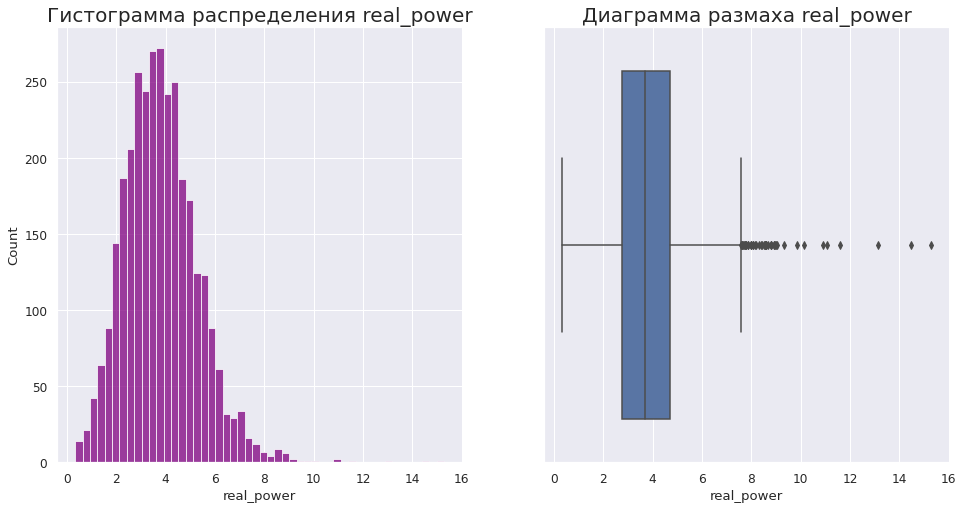

In [26]:
hist_func(data_arc_new,'real_power')

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


count    3214.000000
mean      794.545115
std       332.491076
min        57.000000
25%       571.000000
50%       770.000000
75%       983.000000
max      4189.000000
Name: heating_time, dtype: float64


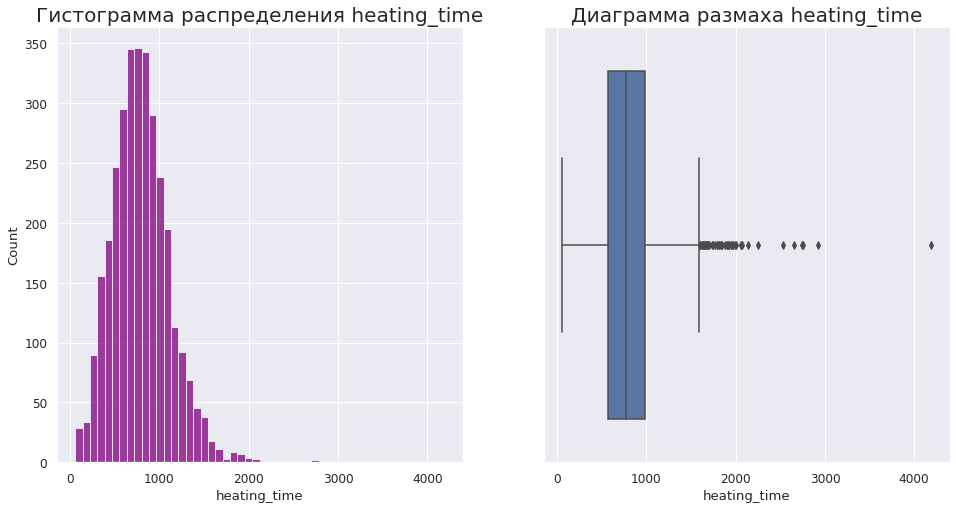

In [27]:
hist_func(data_arc_new,'heating_time')

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


count    3214.000000
mean      655.569107
std       308.976732
min        33.430208
25%       444.626580
50%       620.101427
75%       827.671845
max      4546.405812
Name: electricity_costs, dtype: float64


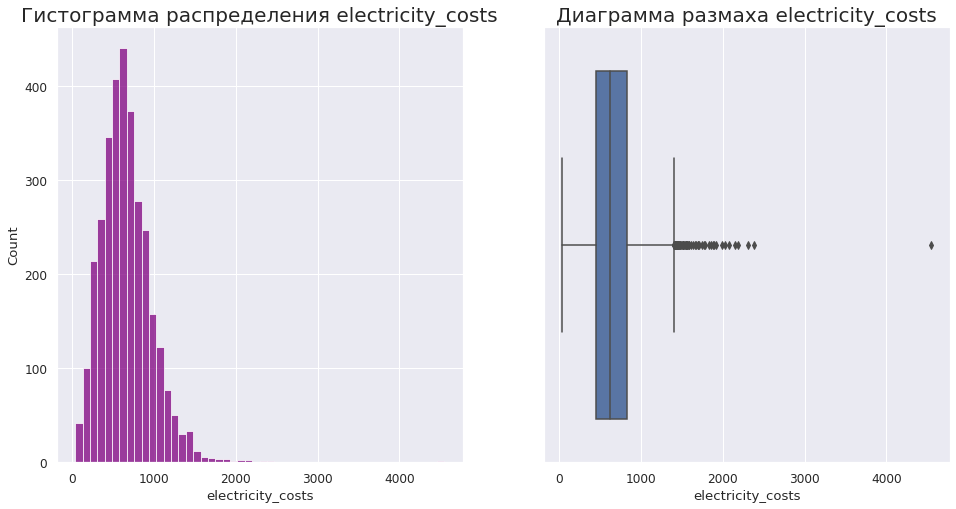

In [28]:
hist_func(data_arc_new,'electricity_costs')

In [29]:
data_arc_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3214 entries, 1 to 3241
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   active_power       3214 non-null   float64
 1   reactive_power     3214 non-null   float64
 2   real_power         3214 non-null   float64
 3   heating_time       3214 non-null   int64  
 4   electricity_costs  3214 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 150.7 KB


После создания новых признаков и группировки мы видим что у новых признаков расспредеоление похожее на нормальное с наличием выбросов. Пока что их оставим.

In [30]:
data_bulk_new.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [31]:
# Приведём названия столбцов к единому стилю
data_bulk_new.columns = ['key',    'bulk_1', 'bulk_2',  'bulk_3',  'bulk_4',  'bulk_5',  'bulk_6',  'bulk_7',
                     'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12', 'bulk_13', 'bulk_14', 'bulk_15']
data_bulk_new.columns

Index(['key', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6',
       'bulk_7', 'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12',
       'bulk_13', 'bulk_14', 'bulk_15'],
      dtype='object')

In [32]:
# Построим тепловую табличку датафрейма
pd.DataFrame(round(data_bulk_new.isna().mean()*100,1)).style.background_gradient('coolwarm')

,0
key,0.000000
bulk_1,91.900000
bulk_2,99.300000
bulk_3,58.500000
bulk_4,67.600000
bulk_5,97.500000
bulk_6,81.600000
bulk_7,99.200000
bulk_8,100.000000
bulk_9,99.400000


Во многих столбцах прпоусков более 80%, удалим их. 

In [33]:
data_bulk_new.drop(['bulk_1','bulk_2', 'bulk_5', 'bulk_6', 'bulk_7','bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_13'], axis= 1 , inplace= True )

In [34]:
# В других заменим пропуски на нули
data_bulk_new = data_bulk_new.fillna(0)
data_bulk_new.isna().sum()

key        0
bulk_3     0
bulk_4     0
bulk_12    0
bulk_14    0
bulk_15    0
dtype: int64

In [35]:
data_bulk_new = data_bulk_new.astype('int')
data_bulk_new.head()

,key,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15
0,1,0,43,206,150,154
1,2,0,73,206,149,154
2,3,0,34,205,152,153
3,4,0,81,207,153,154
4,5,0,78,203,151,152


In [36]:
data_gas_new.head()

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [37]:
# Приводим к единому стилю, а то в названиях столбцов соседствуют русские и английские названия столбцов в разных стилях
data_gas_new.columns = ['key', 'gas']
data_gas_new.columns

Index(['key', 'gas'], dtype='object')

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


count    3239.000000
mean       11.002062
std         6.220327
min         0.008399
25%         7.043089
50%         9.836267
75%        13.769915
max        77.995040
Name: gas, dtype: float64


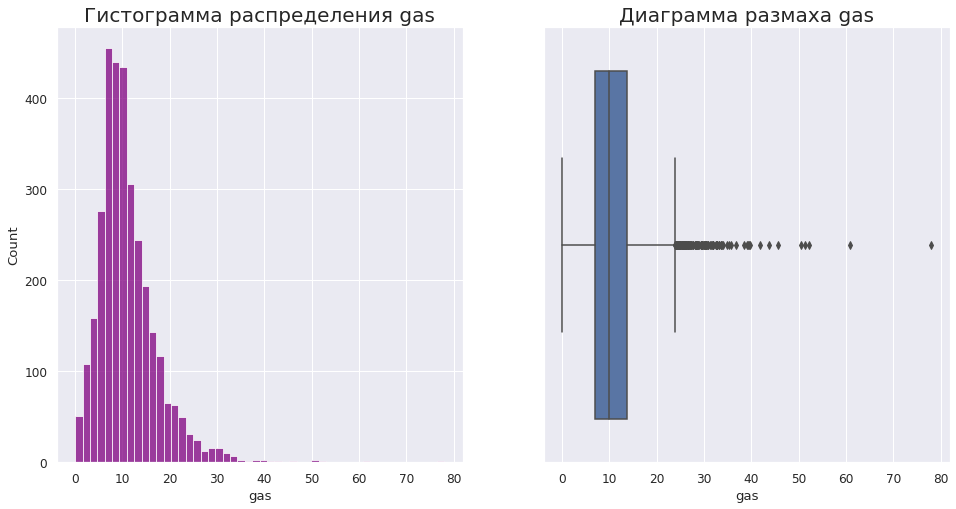

In [38]:
hist_func(data_gas_new,'gas')

In [39]:
data_temp_new.head()

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


In [40]:
# Тоже приводим к единому стилю названия
data_temp_new.columns = ['key', 'time', 'temperature']
data_temp_new.columns

Index(['key', 'time', 'temperature'], dtype='object')

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


count    14665.000000
mean      1590.722741
std         20.394381
min       1191.000000
25%       1580.000000
50%       1590.000000
75%       1599.000000
max       1705.000000
Name: temperature, dtype: float64


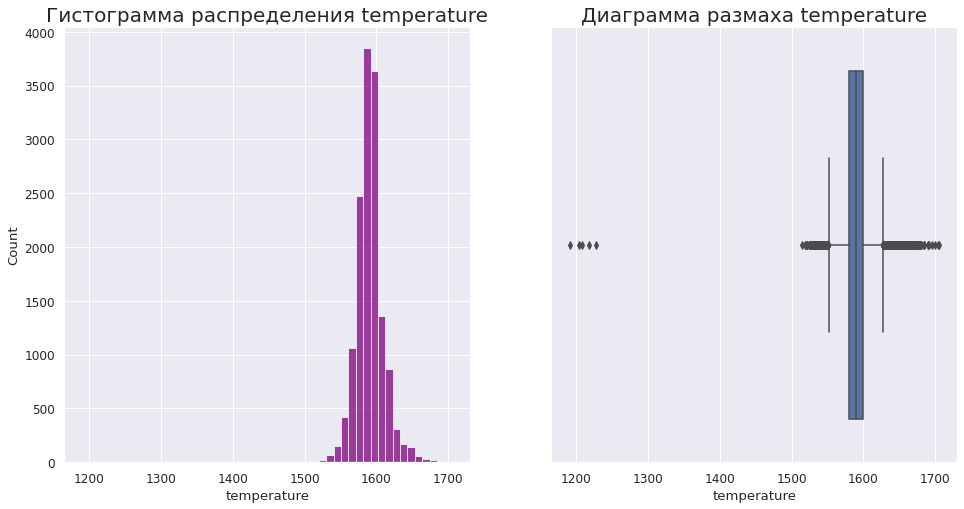

In [41]:
hist_func(data_temp_new, 'temperature')

Есть значения ниже 1400, удалим их.

In [42]:
data_temp_new = data_temp_new.query('temperature > 1400')

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


count    14660.000000
mean      1590.852729
std         19.143141
min       1515.000000
25%       1580.000000
50%       1590.000000
75%       1599.000000
max       1705.000000
Name: temperature, dtype: float64


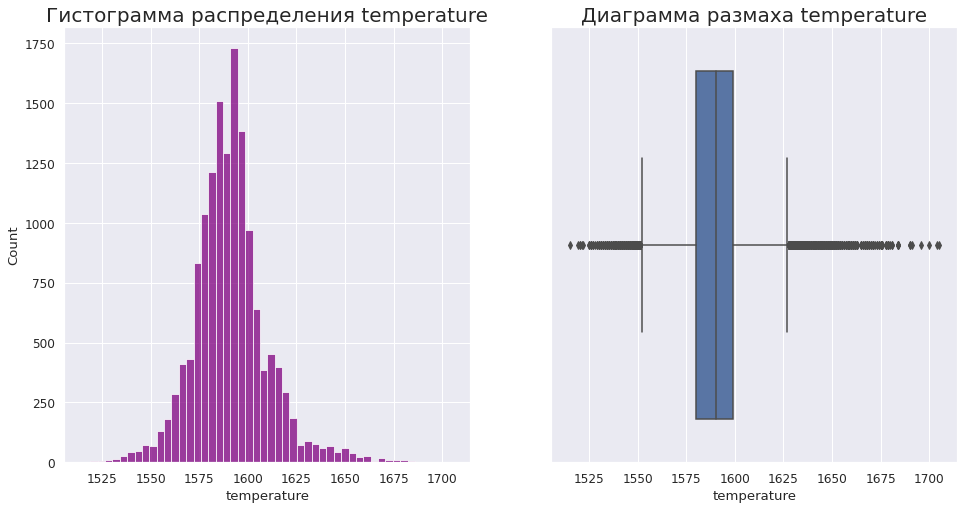

In [43]:
# Проверим что получилось
hist_func(data_temp_new, 'temperature')

In [44]:
pd.DataFrame(round(data_temp_new.isna().mean()*100,1)).style.background_gradient('coolwarm')

,0
key,0.000000
time,0.000000
temperature,0.000000


In [45]:
data_temp_new.head()

,key,time,temperature
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


In [46]:
measurements_rounds = data_temp_new['key'].value_counts().reset_index(name='measurements_rounds').rename(columns={'index': 'key'}).sort_values(by='key', ascending=False)

In [47]:
measurements_rounds.query('measurements_rounds > 1').head()

,key,measurements_rounds
1712,2499,5
968,2498,6
2298,2497,4
602,2496,7
1420,2495,5


С партии 2500 количество измерений равно единице.

Рассчитаем и добавим новый признак - разницу между последним и первым замером температуры.

In [48]:
data_temp_final = data_temp_new.groupby(by = 'key').agg(['first', 'last']).reset_index()
data_temp_final.columns = ['key', 'first_time', 'finish_time', 'first_temp', 'finish_temp']
data_temp_final['time_diff'] = data_temp_final['finish_time'] - data_temp_final['first_time']
data_temp_final['time_diff'] = data_temp_final['time_diff'].dt.seconds
data_temp_final = data_temp_final.query('key < 2500')
data_temp_final.tail()

,key,first_time,finish_time,first_temp,finish_temp,time_diff
2472,2495,2019-08-10 11:27:47,2019-08-10 11:50:47,1570.0,1591.0,1380
2473,2496,2019-08-10 11:56:48,2019-08-10 12:25:13,1554.0,1591.0,1705
2474,2497,2019-08-10 12:37:26,2019-08-10 12:53:28,1571.0,1589.0,962
2475,2498,2019-08-10 12:58:11,2019-08-10 13:23:31,1591.0,1594.0,1520
2476,2499,2019-08-10 13:33:21,2019-08-10 13:58:58,1569.0,1603.0,1537


In [49]:
data_temp_final

,key,first_time,finish_time,first_temp,finish_temp,time_diff
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0,1714
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0,1265
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0,1753
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0,1220
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0,1536
...,...,...,...,...,...,...
2472,2495,2019-08-10 11:27:47,2019-08-10 11:50:47,1570.0,1591.0,1380
2473,2496,2019-08-10 11:56:48,2019-08-10 12:25:13,1554.0,1591.0,1705
2474,2497,2019-08-10 12:37:26,2019-08-10 12:53:28,1571.0,1589.0,962
2475,2498,2019-08-10 12:58:11,2019-08-10 13:23:31,1591.0,1594.0,1520


In [50]:
data_wire_new.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
data_wire_new.columns = ['key', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_5', 'wire_6', 'wire_7', 'wire_8', 'wire_9']
data_wire_new.columns

Index(['key', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_5', 'wire_6',
       'wire_7', 'wire_8', 'wire_9'],
      dtype='object')

In [52]:
pd.DataFrame(round(data_wire_new.isna().mean()*100,1)).style.background_gradient('coolwarm')

,0
key,0.000000
wire_1,0.800000
wire_2,65.000000
wire_3,98.000000
wire_4,99.500000
wire_5,100.000000
wire_6,97.600000
wire_7,99.600000
wire_8,99.400000
wire_9,99.100000


По тепловой табличке видим, что во многих столбцах пропусков свыше 80%, удалим их.

In [53]:
data_wire_new.drop(['wire_3', 'wire_4', 'wire_5', 'wire_6', 'wire_7', 'wire_8', 'wire_9'], axis= 1 , inplace= True )
data_wire_new = data_wire_new.fillna(0)
data_wire_new.head()

,key,wire_1,wire_2
0,1,60.059998,0.00000
1,2,96.052315,0.00000
2,3,91.160157,0.00000
3,4,89.063515,0.00000
4,5,89.238236,9.11456


Привели названия столбцов к стандартному виду. Обработали пропуски и выбросы: удалили столбцы, где пропуски превышают 80%. Также убрали температуру ниже 1400, когда сплав уже остывал и отрицательную мощность.
Добавили дополнительные признаки.
Подготовили данные для объединения в общий датафрейм. Удалили данные с одним измерением температуры.

# Шаг 3: Объединение данных

Объединим интересующие нас таблицы.

In [54]:
data =  data_arc_new.merge(data_temp_final, on='key', how='inner')
data = data.merge(data_gas_new, on='key', how='inner')
data = data.merge(data_bulk_new, on='key', how='inner')
data = data.merge(data_wire_new, on='key', how='inner')

In [55]:
desc_dat(data)

Название: DataFrame

Количество дубликатов: 0

Количество пропусков:
key                  0
active_power         0
reactive_power       0
real_power           0
heating_time         0
electricity_costs    0
first_time           0
finish_time          0
first_temp           0
finish_temp          0
time_diff            0
gas                  0
bulk_3               0
bulk_4               0
bulk_12              0
bulk_14              0
bulk_15              0
wire_1               0
wire_2               0
dtype: int64

Размер: (2329, 19)



,key,active_power,reactive_power,real_power,heating_time,electricity_costs,first_time,finish_time,first_temp,finish_temp,time_diff,gas,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,wire_1,wire_2
0,1,3.036730,2.142821,3.718736,1098,770.282114,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1613.0,1714,29.749986,0,43,206,150,154,60.059998,0.000000
1,2,2.139408,1.453357,2.588349,811,481.760005,2019-05-03 11:34:04,2019-05-03 11:55:09,1581.0,1602.0,1265,12.555561,0,73,206,149,154,96.052315,0.000000
2,3,4.063641,2.937457,5.019223,655,722.837668,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1599.0,1753,28.554793,0,34,205,152,153,91.160157,0.000000
3,4,2.706489,2.056992,3.400038,741,683.455597,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0,1220,18.841219,0,81,207,153,154,89.063515,0.000000
4,5,2.252950,1.687991,2.816980,869,512.169934,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0,1536,5.413692,0,78,203,151,152,89.238236,9.114560
5,6,2.725274,1.881313,3.313074,952,839.231310,2019-05-03 13:46:41,2019-05-03 14:11:38,1543.0,1596.0,1497,11.273392,0,117,204,201,154,99.109917,9.114560
6,7,2.626877,1.960419,3.283913,673,613.576982,2019-05-03 14:16:36,2019-05-03 14:45:40,1586.0,1599.0,1744,9.836267,0,117,204,152,154,98.061600,0.000000
7,8,2.678958,2.096952,3.405956,913,619.129542,2019-05-03 14:53:46,2019-05-03 15:20:41,1577.0,1598.0,1615,15.171553,0,99,410,252,153,155.282394,0.000000
8,9,3.520820,2.527365,4.335261,625,570.113675,2019-05-03 15:36:33,2019-05-03 16:06:44,1587.0,1592.0,1811,8.216623,0,117,107,99,203,113.393279,9.143681
9,10,3.118778,2.154941,3.791005,825,533.482050,2019-05-03 16:13:59,2019-05-03 16:39:50,1574.0,1593.0,1551,6.529891,0,0,203,102,204,81.244796,12.376000


,key,active_power,reactive_power,real_power,heating_time,electricity_costs,first_temp,finish_temp,time_diff,gas,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,wire_1,wire_2
count,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000,2329.000000
mean,1251.832546,3.125033,2.300522,3.884654,807.600687,669.741514,1587.386003,1593.365393,2321.810219,11.375600,47.348218,37.303564,208.415629,153.853585,119.952769,102.443601,17.609859
std,714.762400,1.221007,0.903968,1.518157,340.897332,319.531949,23.619841,11.200915,1385.191527,6.392041,75.310430,58.643238,157.062272,81.404354,84.640443,43.539993,33.624771
min,1.000000,0.267676,0.196228,0.331897,57.000000,33.430208,1519.000000,1541.000000,270.000000,0.008399,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,630.000000,2.293900,1.669572,2.843058,581.000000,457.864703,1571.000000,1587.000000,1579.000000,7.282948,0.000000,0.000000,105.000000,105.000000,0.000000,73.207679,0.000000
50%,1255.000000,3.035365,2.225398,3.767499,778.000000,630.714148,1587.000000,1593.000000,2045.000000,10.100950,0.000000,0.000000,206.000000,149.000000,107.000000,101.119201,0.000000
75%,1868.000000,3.834300,2.829159,4.769421,993.000000,841.398018,1603.000000,1598.000000,2791.000000,14.216688,80.000000,77.000000,282.000000,204.000000,204.000000,128.091599,23.102560
max,2499.000000,12.375636,8.949049,15.288271,4189.000000,4546.405812,1660.000000,1653.000000,23674.000000,77.995040,454.000000,281.000000,1849.000000,636.000000,405.000000,330.314424,282.780152


Удалим признак key а также first_time и finish_time

In [56]:
data.drop(['key', 'first_time', 'finish_time'], axis= 1 , inplace= True )

In [57]:
# Проверим что получилось
data.sample(5)

,active_power,reactive_power,real_power,heating_time,electricity_costs,first_temp,finish_temp,time_diff,gas,bulk_3,bulk_4,bulk_12,bulk_14,bulk_15,wire_1,wire_2
394,5.195914,3.675884,6.369420,1341,1113.438971,1589.0,1615.0,3490,17.448153,0,176,412,259,154,171.381607,18.06584
1382,2.443334,1.743296,3.004003,693,443.225773,1567.0,1597.0,1255,4.858857,0,107,205,101,106,122.990398,0.00000
798,1.699928,1.240709,2.105839,371,220.633080,1624.0,1620.0,1416,0.008399,124,0,0,0,0,100.105202,50.09576
2242,4.473412,3.283702,5.557419,1084,1052.903604,1583.0,1590.0,4410,14.872096,0,34,307,142,160,79.148163,20.11672
927,1.117880,0.801024,1.375320,368,253.764655,1596.0,1577.0,1040,12.651844,0,0,255,152,102,45.115200,0.00000


Мы объединили все необходимые датасеты в один итоговый. В нем пропуски и дубликаты отсутствуют, также удалили признак key. Итоговый размер датасета (2329, 19).

# Шаг 4: Исследовательский анализ и предобработка данных объединённого датафрейма

In [58]:
# Определим признаки
num_col = ['active_power', 'reactive_power', 'real_power', 'heating_time',
       'electricity_costs', 'first_temp', 'finish_temp', 'time_diff', 'gas',
       'bulk_3', 'bulk_4', 'bulk_12', 'bulk_14', 'bulk_15', 'wire_1',
       'wire_2']

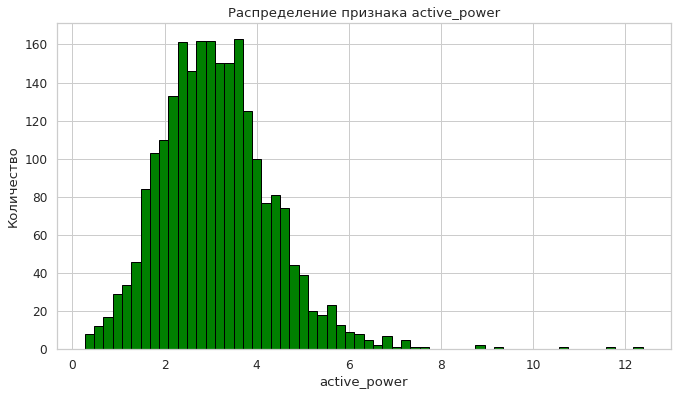

count    2329.000000
mean        3.125033
std         1.221007
min         0.267676
25%         2.293900
50%         3.035365
75%         3.834300
max        12.375636
Name: active_power, dtype: float64


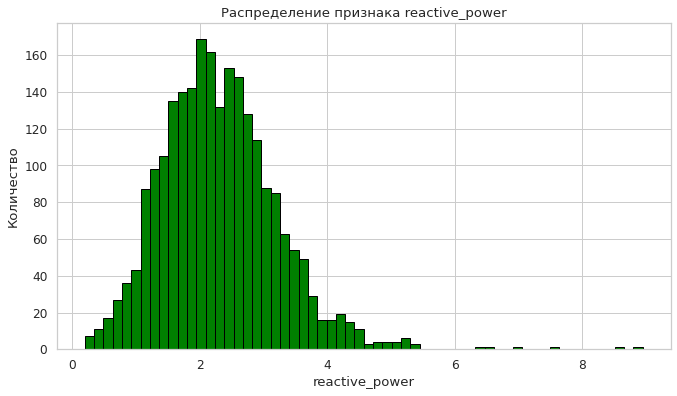

count    2329.000000
mean        2.300522
std         0.903968
min         0.196228
25%         1.669572
50%         2.225398
75%         2.829159
max         8.949049
Name: reactive_power, dtype: float64


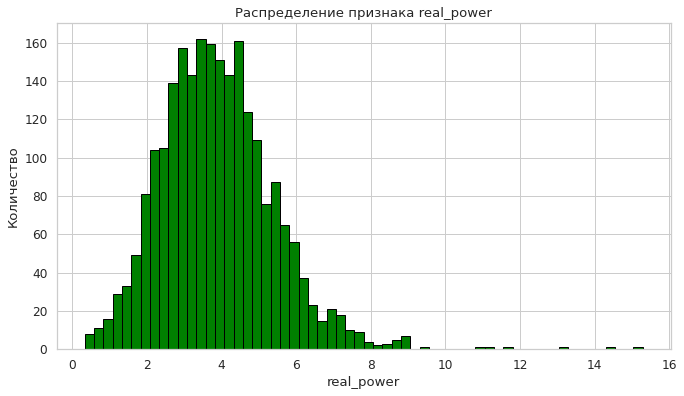

count    2329.000000
mean        3.884654
std         1.518157
min         0.331897
25%         2.843058
50%         3.767499
75%         4.769421
max        15.288271
Name: real_power, dtype: float64


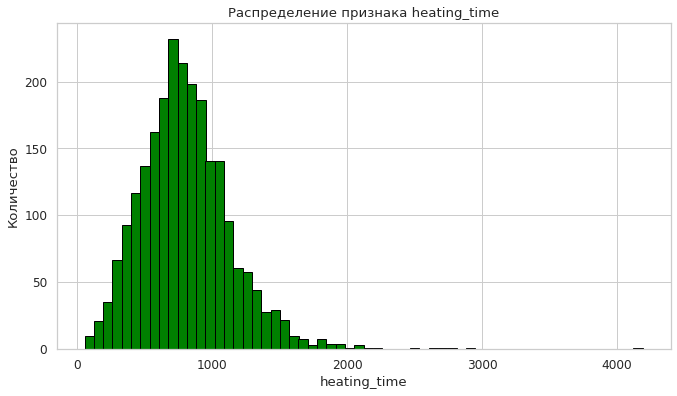

count    2329.000000
mean      807.600687
std       340.897332
min        57.000000
25%       581.000000
50%       778.000000
75%       993.000000
max      4189.000000
Name: heating_time, dtype: float64


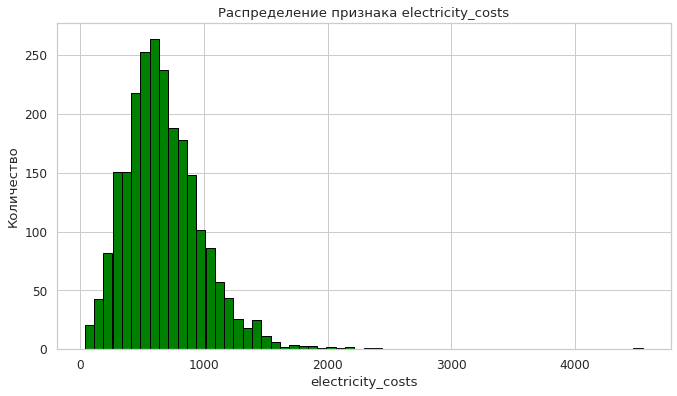

count    2329.000000
mean      669.741514
std       319.531949
min        33.430208
25%       457.864703
50%       630.714148
75%       841.398018
max      4546.405812
Name: electricity_costs, dtype: float64


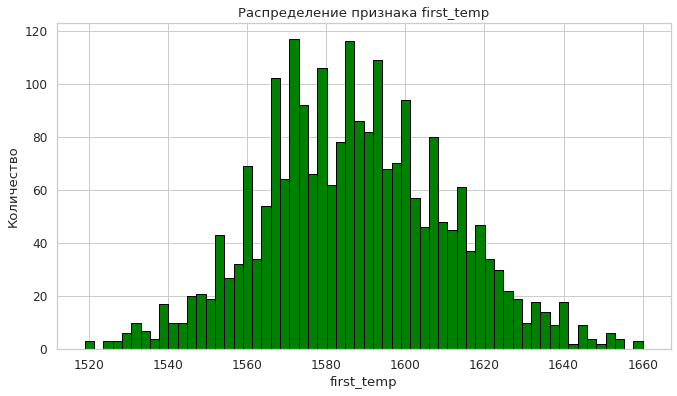

count    2329.000000
mean     1587.386003
std        23.619841
min      1519.000000
25%      1571.000000
50%      1587.000000
75%      1603.000000
max      1660.000000
Name: first_temp, dtype: float64


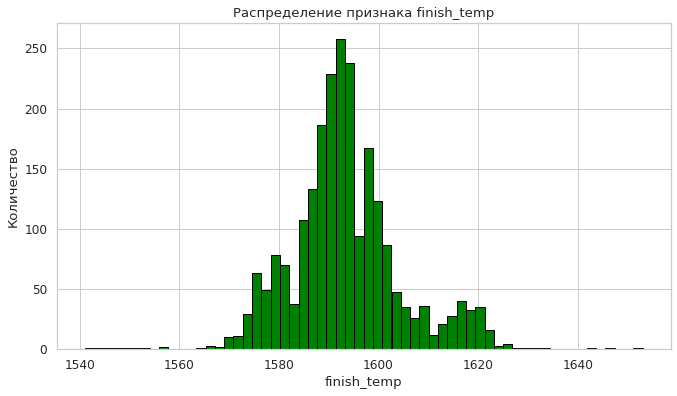

count    2329.000000
mean     1593.365393
std        11.200915
min      1541.000000
25%      1587.000000
50%      1593.000000
75%      1598.000000
max      1653.000000
Name: finish_temp, dtype: float64


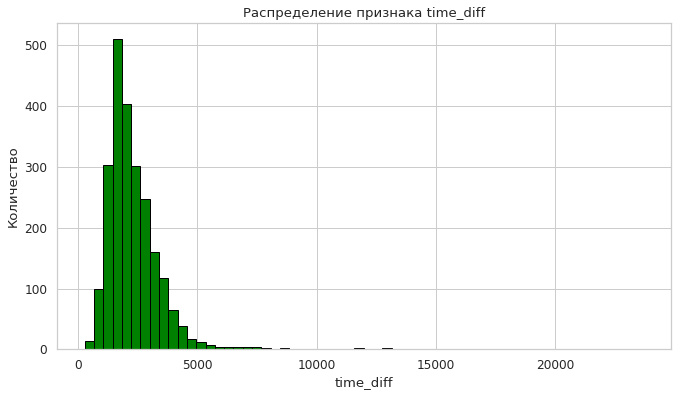

count     2329.000000
mean      2321.810219
std       1385.191527
min        270.000000
25%       1579.000000
50%       2045.000000
75%       2791.000000
max      23674.000000
Name: time_diff, dtype: float64


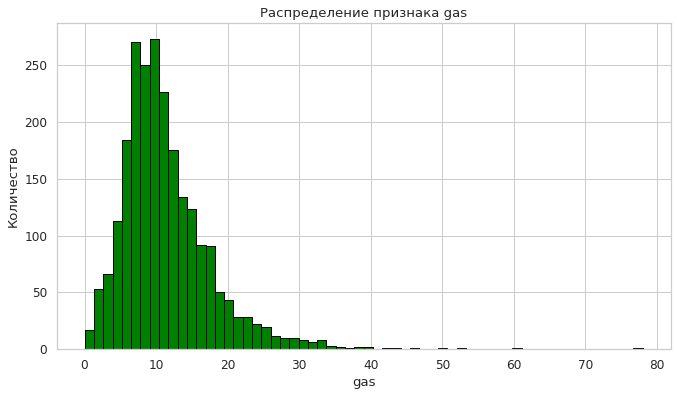

count    2329.000000
mean       11.375600
std         6.392041
min         0.008399
25%         7.282948
50%        10.100950
75%        14.216688
max        77.995040
Name: gas, dtype: float64


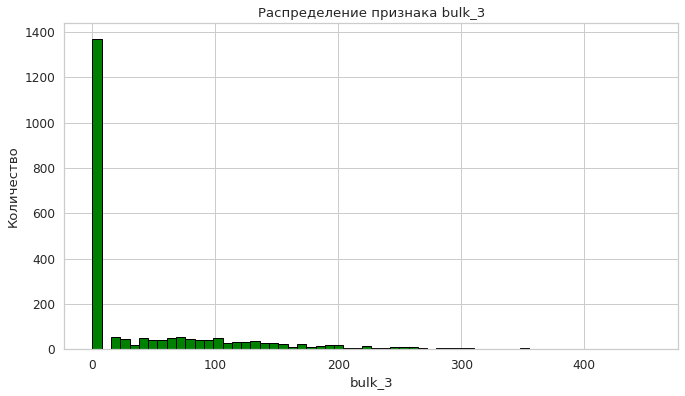

count    2329.000000
mean       47.348218
std        75.310430
min         0.000000
25%         0.000000
50%         0.000000
75%        80.000000
max       454.000000
Name: bulk_3, dtype: float64


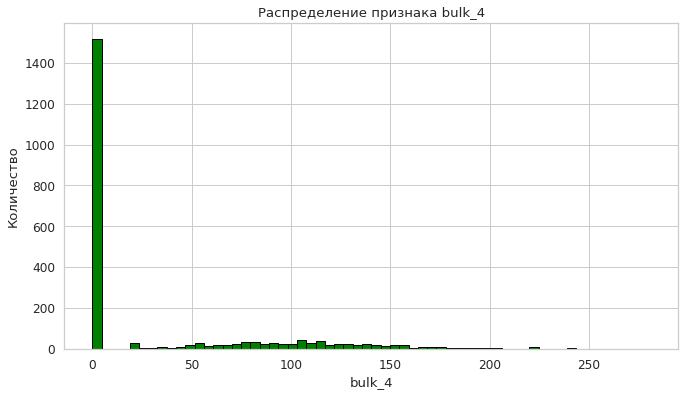

count    2329.000000
mean       37.303564
std        58.643238
min         0.000000
25%         0.000000
50%         0.000000
75%        77.000000
max       281.000000
Name: bulk_4, dtype: float64


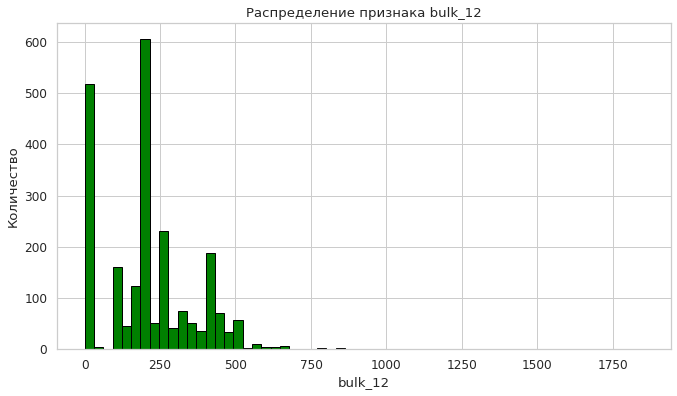

count    2329.000000
mean      208.415629
std       157.062272
min         0.000000
25%       105.000000
50%       206.000000
75%       282.000000
max      1849.000000
Name: bulk_12, dtype: float64


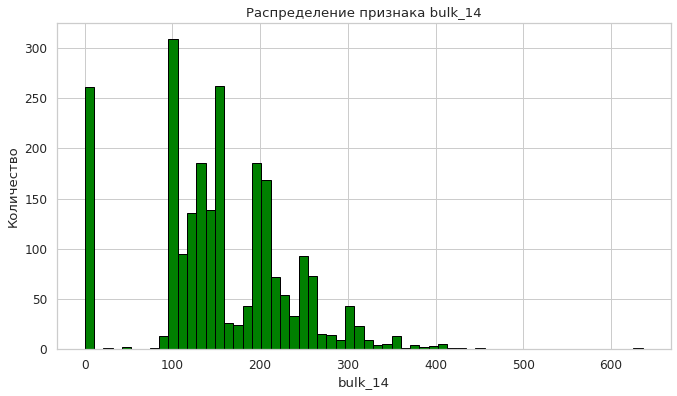

count    2329.000000
mean      153.853585
std        81.404354
min         0.000000
25%       105.000000
50%       149.000000
75%       204.000000
max       636.000000
Name: bulk_14, dtype: float64


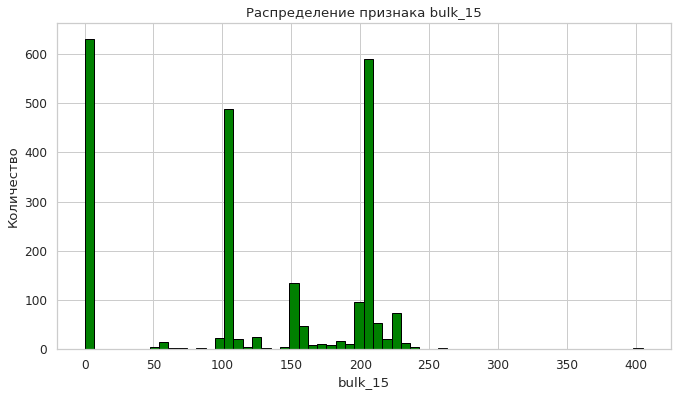

count    2329.000000
mean      119.952769
std        84.640443
min         0.000000
25%         0.000000
50%       107.000000
75%       204.000000
max       405.000000
Name: bulk_15, dtype: float64


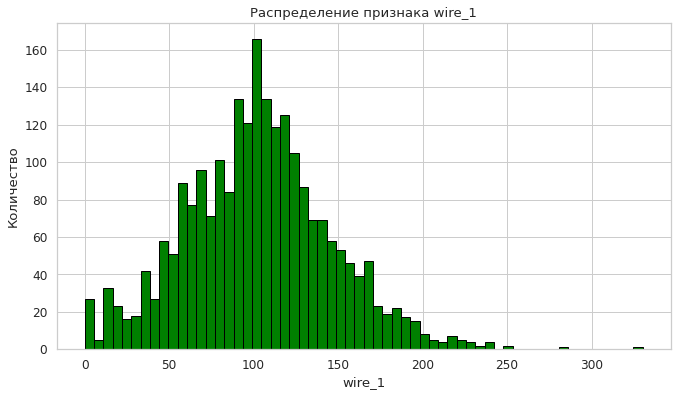

count    2329.000000
mean      102.443601
std        43.539993
min         0.000000
25%        73.207679
50%       101.119201
75%       128.091599
max       330.314424
Name: wire_1, dtype: float64


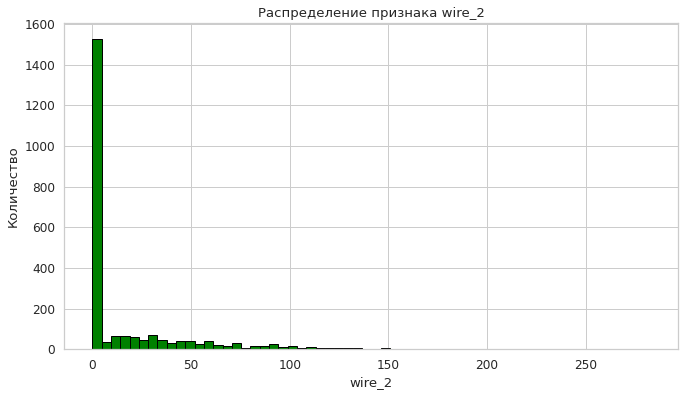

count    2329.000000
mean       17.609859
std        33.624771
min         0.000000
25%         0.000000
50%         0.000000
75%        23.102560
max       282.780152
Name: wire_2, dtype: float64


In [59]:
# Построим гистограммы распределения с информацией
for i in range(len(num_col)):
    sns.set_style('whitegrid')
    plt.figure(figsize=(11, 6))
    plt.hist(data[num_col[i]], color = 'green', edgecolor = 'black', bins = 60)
    plt.title(f"Распределение признака {num_col[i]}")
    plt.ylabel("Количество")
    plt.xlabel(num_col[i])
    plt.show()
    print(data[num_col[i]].describe())

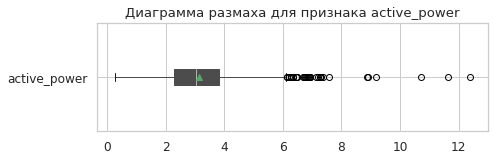

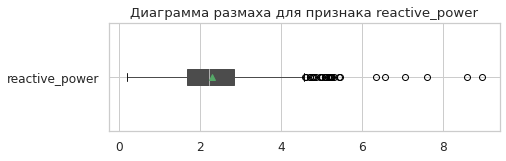

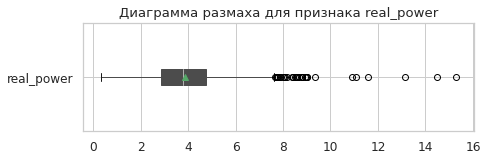

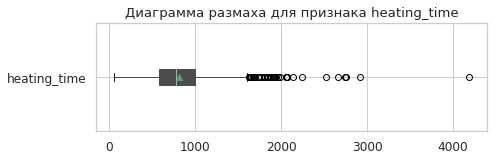

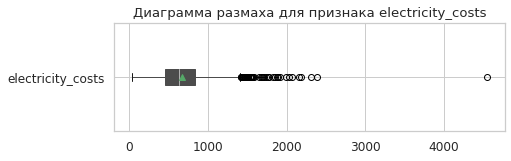

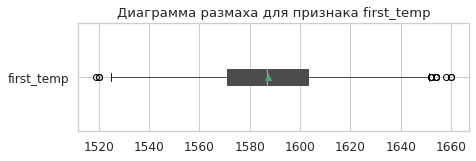

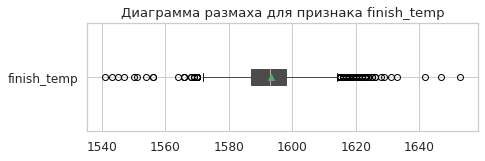

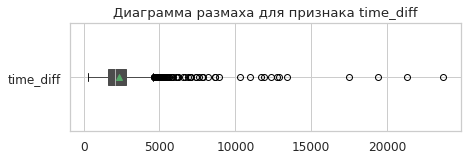

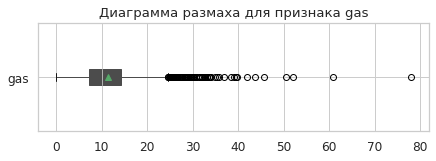

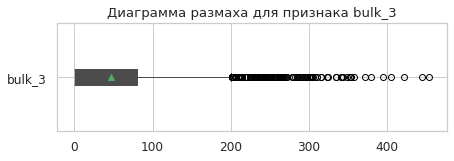

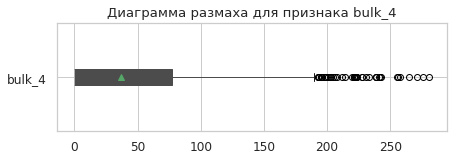

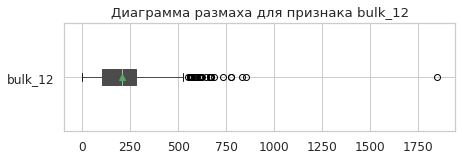

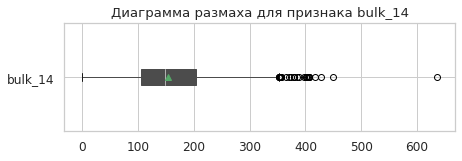

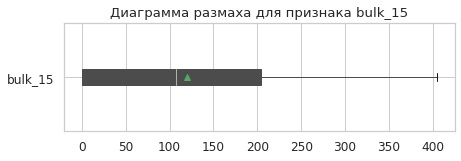

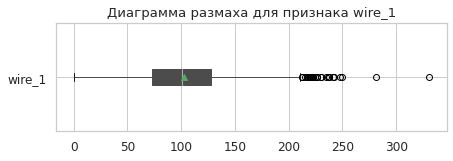

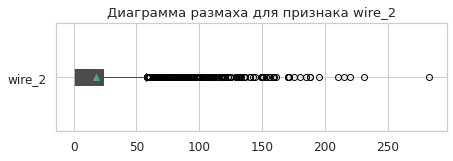

In [60]:
# Построим диаграммы размаха
for i in range(len(num_col)):
    plt.figure(figsize=(7, 2))
    data.boxplot(num_col[i], patch_artist=True, vert=False, showmeans=True )
    plt.title(f"Диаграмма размаха для признака {num_col[i]}")
   
    plt.show()

После обработки датасета построили гистограммы и диаграммы размаха для всех признаков. В большинстве случаев мы наблюдаем нормальное распределение признаков, кроме признаков bulk_3, bulk_4, bulk_15, wire_2.

У каждого из признаков есть выбросы, которые пока оставим.



Построим тепловую карту.

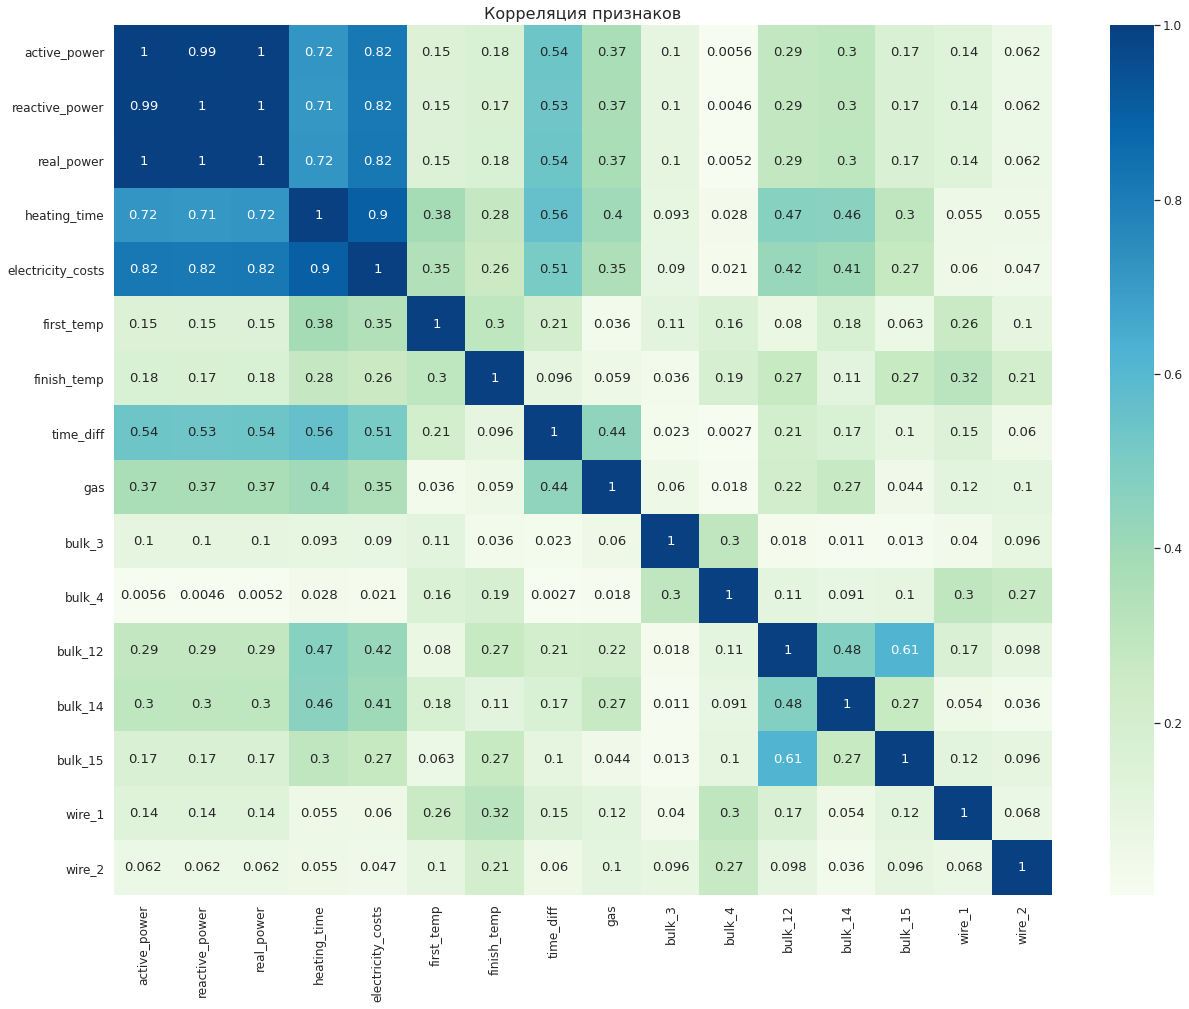

In [61]:
plt.figure(figsize=(21, 16))
fig = sns.heatmap(data.corr().abs(), cmap='GnBu', annot=True)
plt.title('Корреляция признаков', fontsize=16)
plt.setp(fig.get_xticklabels(), rotation=90)
plt.show()

Высокая корреляция наблюдается между: 'active_power', 'reactive_power', 'real_power' и 'heating_time'.

# Шаг 5: Подготовка данных

In [62]:
RANDOM_STATE = 241224
TEST_SIZE = 0.25

In [63]:
X = data.drop('finish_temp', axis=1)
y = data['finish_temp']


X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE
)

In [64]:
print('Размер X_train: ', X_train.shape)
print('Размер X_test: ', X_test.shape)
print('Размер y_train: ', y_train.shape)
print('Размер y_test: ', y_test.shape)

Размер X_train:  (1746, 15)
Размер X_test:  (583, 15)
Размер y_train:  (1746,)
Размер y_test:  (583,)


Выборки разделили, данные подготовили.

# Шаг 6: Обучение моделей машинного обучения

RandomForestRegressor

In [65]:
%%time

model = RandomForestRegressor()
params = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 4, 8],
    'bootstrap': [True, False],
    'random_state': [RANDOM_STATE]
}
rf_grid = GridSearchCV(model, params, cv=5, scoring='neg_mean_absolute_error')
rf_grid.fit(X_train, y_train)
result_rf = abs(rf_grid.best_score_)
print(f'MAE на тренировочной: {result_rf:.2f}')

MAE на тренировочной: 6.37
CPU times: user 1min 12s, sys: 106 ms, total: 1min 12s
Wall time: 1min 12s


LGBMRegressor

In [66]:
%%time

model = LGBMRegressor()
params = {
    'metric': ['mae'],
    'max_depth': [10], 
    'num_leaves': [10],  
    'learning_rate': [0.05],  
    'random_state': [RANDOM_STATE],
}
lgbm_grid = GridSearchCV(model, params, cv=5, verbose=2, scoring='neg_mean_absolute_error')
lgbm_grid.fit(X_train, y_train)
result_lgbm = abs(lgbm_grid.best_score_)
print(f'MAE на тренировочной: {result_lgbm:.2f}')

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END learning_rate=0.05, max_depth=10, metric=mae, num_leaves=10, random_state=241224; total time=   0.7s
[CV] END learning_rate=0.05, max_depth=10, metric=mae, num_leaves=10, random_state=241224; total time=   0.7s
[CV] END learning_rate=0.05, max_depth=10, metric=mae, num_leaves=10, random_state=241224; total time=   0.5s
[CV] END learning_rate=0.05, max_depth=10, metric=mae, num_leaves=10, random_state=241224; total time=   0.5s
[CV] END learning_rate=0.05, max_depth=10, metric=mae, num_leaves=10, random_state=241224; total time=   0.5s
MAE на тренировочной: 6.32
CPU times: user 3.52 s, sys: 84.1 ms, total: 3.61 s
Wall time: 3.53 s


CatBoostRegressor

In [67]:
%%time

model = CatBoostRegressor(verbose=False)
params = {
    'loss_function':['MAE'],
    'depth': [5], 
    'learning_rate': [0.1], 
    'n_estimators': [500],  
    'random_state': [RANDOM_STATE],
}
cb_grid = GridSearchCV(model, params, cv=5,verbose=2, scoring='neg_mean_absolute_error')
cb_grid.fit(X_train, y_train)
result_cb = abs(cb_grid.best_score_)
print(f'MAE на тренировочной: {result_cb:.2f}')

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END depth=5, learning_rate=0.1, loss_function=MAE, n_estimators=500, random_state=241224; total time=   1.8s
[CV] END depth=5, learning_rate=0.1, loss_function=MAE, n_estimators=500, random_state=241224; total time=   1.7s
[CV] END depth=5, learning_rate=0.1, loss_function=MAE, n_estimators=500, random_state=241224; total time=   1.9s
[CV] END depth=5, learning_rate=0.1, loss_function=MAE, n_estimators=500, random_state=241224; total time=   1.6s
[CV] END depth=5, learning_rate=0.1, loss_function=MAE, n_estimators=500, random_state=241224; total time=   1.6s
MAE на тренировочной: 6.26
CPU times: user 6.26 s, sys: 206 ms, total: 6.46 s
Wall time: 10.3 s


Провели обучение моделей RandomForestRegressor, CatBoostRegressor, LGBMRegressor, использую следующие соотношения разбивки на выборки: 75 к 25. С заданным параметром RANDOM_STATE = 241224 и получили следующие результаты.

На тренировочной выборке модели дали следующие результаты:

- RandomForestRegressor: MAE на тренировочной: 6.37
        
- LGBMRegressor: MAE на тренировочной: 6.32, где лучшие параметры: {'learning_rate': 0.05, 'max_depth': 10, 'metric': 'mae', 'num_leaves': 10, 'random_state': 241224}

- CatBoostRegressor: MAE на тренировочной: 6.26, где лучшие параметры: {'depth': 5, 'learning_rate': 0.1, 'loss_function': 'MAE', 'n_estimators': 500, 'random_state': 241224}


# Шаг 7: Выбор лучшей модели

In [68]:
# Построим тепловую табличку для результатов
data = {'MAE на тренировочной':[result_rf, result_cb, result_lgbm]}
index = ['RandomForestRegressor', 'CatBoostRegressor', 'LGBMRegressor']
data_final = pd.DataFrame(data=data, index=index)
pd.set_option('precision', 2)
display(data_final.sort_values(by='MAE на тренировочной', ascending=True).style.background_gradient(cmap='Blues', axis=0))

,MAE на тренировочной
CatBoostRegressor,6.26
LGBMRegressor,6.32
RandomForestRegressor,6.37


С незначительным преимуществом лучшая модель CatBoostRegressor.

In [69]:
# Проверим модель на тестовой выборке

model = CatBoostRegressor(
    depth=5,
    learning_rate=0.1,
    loss_function='MAE',
    n_estimators=500,
    random_state=RANDOM_STATE,
    verbose = False
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
result_cb_t = mean_absolute_error(y_test, predictions)
print(f'MAE на тестовой: {result_cb_t:.2f}')

MAE на тестовой: 5.72


Модель CatBoostRegressor показала MAE на тестовой: 5.72, что подходит нам по условию MAE <= 6.8

In [70]:
# Рассчитаем метрику r2 на тестовой выборке
r2 = r2_score(y_test, predictions)

print(f'r2 на тестовой выборке: {r2:.2f}')

r2 на тестовой выборке: 0.46


r2 на тестовой выборке 0.46, значит модель имеет среднее качество.

Важность признаков у лучшей модели

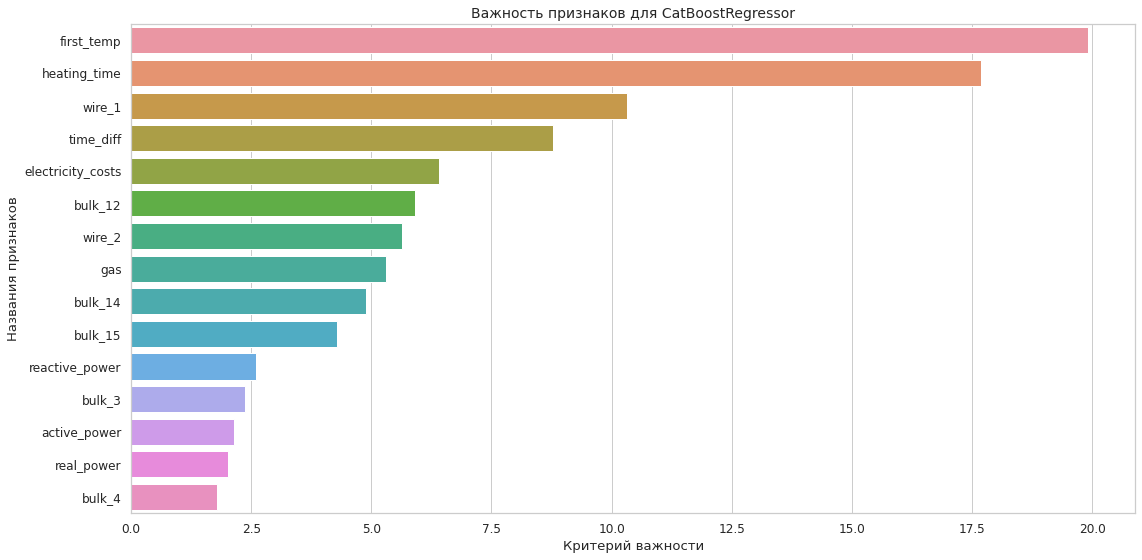

In [147]:
# Построим диаграмму важности признаков лучшей модели
feature_importance_data = {
    'features': X_test.columns,
    'feature_importances': model.feature_importances_,
}
feature_importance_data = pd.DataFrame(feature_importance_data)
feature_importance_data.sort_values(by='feature_importances', ascending=False, inplace=True)
plt.figure(figsize=(18, 9))
sns.barplot(x=feature_importance_data['feature_importances'], y=feature_importance_data['features'])
plt.title('Важность признаков для CatBoostRegressor', fontsize=14)
plt.xlabel('Критерий важности')
plt.ylabel('Названия признаков')
plt.show()

Наиболее важными признаками являются температура нагрева и время нагрева.

In [149]:
# Сделаем проверку на адекватность
dummy_mean = DummyRegressor('median')
dummy_mean.fit(X_train, y_train)
dummy_prediction = dummy_mean.predict(X_train)
mae_score = mean_absolute_error(y_train, dummy_prediction)

print(f'MAE модели с постоянным предсказанием на тестовой выборке: {mae_score:.2f}')

MAE модели с постоянным предсказанием на тестовой выборке: 8.16


/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:70: FutureWarning: Pass strategy=median as keyword args. From version 1.0 (renaming of 0.25) passing these as positional arguments will result in an error
  warnings.warn(f"Pass {args_msg} as keyword args. From version "


CatBoostRegressor показал заметно лучшие результаты чем у постоянной модели 5.72 против 8.16.

Мы провели обучение моделей RandomForestRegressor, CatBoostRegressor, LGBMRegressor, использую следующие соотношения разбивки на выборки: 75 к 25. Также с заданным параметром RANDOM_STATE = 241224 и получили следующие результаты.

1. Размер выборок:
- Размер X_train: (1746, 15)
- Размер X_test: (583, 15)
- Размер y_train: (1746,)
- Размер y_test: (583,)

2. На тренировочной выборке модели дали следующие результаты:
- RandomForestRegressor: MAE на тренировочной: 6.37
- CatBoostRegressor: MAE на тренировочной: 6.26, где лучшие параметры: {'depth': 5, 'learning_rate': 0.1, 'loss_function': 'MAE', 'n_estimators': 500, 'random_state': 241224}
- LGBMRegressor: MAE на тренировочной: 6.32, где лучшие параметры: {'learning_rate': 0.05, 'max_depth': 10, 'metric': 'mae', 'num_leaves': 10, 'random_state': 241224}.

3. Лучшая модель на тренировочной выборке CatBoostRegressor. Модель CatBoostRegressor показала MAE на тестовой: 5.72, что меньше поставленного условия - MAE на тестовой должно быть <= 6.8.


4. Рассчитали, что r2 на тестовой выборке: 0.46 - в среднем диапазоне, что соответственно говорит о среднем качестве модели.


5. Выявили важность признаков. Для модели наиболее важными признаками являются:
- температура нагрева
- время нагрева
- затраты энергии.
6. Для проверки адекватности модели был обучен DummyRegressor с предсказанием медианного значения целевой переменной. Его MAE на тренировочной выборке составил 8.16. CatBoostRegressor показал заметно лучшие результаты, уменьшив MAE до 5.72. Это подтверждает, что наша модель значительно превосходит базовый уровень.


# Шаг 8: Общий вывод и рекомендации заказчику

Цель проекта - оптимизация производственных расходов металлургического комбината, с помощью построения модели машинного обучения, которая предсказывает температуру сплава.

- Целевая переменная target - последняя температура по всей партии
- Целевая метрика - MAE (нужно получить не более 6.8 на тесте)

Данные состоят из нескольких файлов, полученных из разных источников:

- data_arc_new.csv — данные об электродах;

- data_bulk_new.csv — данные о подаче сыпучих материалов (объём);

- data_bulk_time_new.csv — данные о подаче сыпучих материалов (время);

- data_gas_new.csv — данные о продувке сплава газом;

- data_temp_new.csv — результаты измерения температуры;

- data_wire_new.csv — данные о проволочных материалах (объём);

- data_wire_time_new.csv — данные о проволочных материалах (время).

Которые в процессе работы были обработаны и подготовлены для построения модели.

Файл data_arc_new.csv — данные об электродах

Переименованы столбцы по правилам PEP8.
Удалены данные партий с отрицательной реактивной мощностью.
Произведен расчет полной мощности, расчет времени нагрева в секундах, а также затраты энергии, данные добавлены в новые столбцы

Файл data_bulk_new.csv - данные о подаче сыпучих материалов (объём)

Переименованы столбцы по правилам PEP8
Удаленны признаки, в которых более 80% пропущенных значений, оставшиеся заменены нулями.

Файл data_gas_new.csv — данные о продувке сплава газом

Переименованы столбцы по правилам PEP8.

Файл data_temp_new.csv — результаты измерения температуры

Переименованы столбцы по правилам PEP8
Удалены партии с температурой менее 1400, а также партии, где один замер температуры и партии с пропущенными значениями:
Выполнено определение начальной и конечной температур замеров.

Файл data_wire_new.csv — данные о проволочных материалах (объём)

Переименованы столбцы по правилам PEP8
Удаленны признаки, в которых изначально имеется более 80% пропущенных значений, также заполним оставшиеся пропущенные значения нулями.

Для объединения таблиц используем все, кроме data_bulk_time_new и data_wire_time_new. Объединили все необходимые датасеты в один итоговый. В нем пропуски и дубликаты отсутствуют, также удалили признак key. Итоговый размер датасета (2329, 19).

После обработки датасета мы построили гистограммы и диаграммы размаха для всех признаков. В большинстве случаев мы наблюдаем нормальное распределение признаков, кроме признаков bulk_3, bulk_4, bulk_15, wire_2. У каждого из признаков есть выбросы, которые пока оставляем.

Построив тепловую карту видим, что высокая корреляция признаков наблюдается между: 'active_power', 'reactive_power', 'real_power' и 'heating_time'.



Мы провели обучение моделей RandomForestRegressor, CatBoostRegressor, LGBMRegressor, используя следующие соотношения разбивки на выборки: 75 к 25. Также с заданным параметром RANDOM_STATE = 241224 и получили следующие результаты:

1. Размер выборок:
- Размер X_train: (1746, 15)
- Размер X_test: (583, 15)
- Размер y_train: (1746,)
- Размер y_test: (583,)

2. На тренировочной выборке модели дали следующие результаты:
- RandomForestRegressor: MAE на тренировочной: 6.37
- CatBoostRegressor: MAE на тренировочной: 6.26, где лучшие параметры: {'depth': 5, 'learning_rate': 0.1, 'loss_function': 'MAE', 'n_estimators': 500, 'random_state': 241224}
- LGBMRegressor: MAE на тренировочной: 6.32, где лучшие параметры: {'learning_rate': 0.05, 'max_depth': 10, 'metric': 'mae', 'num_leaves': 10, 'random_state': 241224}.

3. Лучшая модель на тренировочной выборке CatBoostRegressor. Модель CatBoostRegressor показала MAE на тестовой: 5.72, что меньше поставленного условия - MAE на тестовой должно быть <= 6.8.


4. Рассчитали, что r2 на тестовой выборке: 0.46 - в среднем диапазоне, что соответственно говорит о среднем качестве модели.


5. Выявили важность признаков. Для модели наиболее важными признаками являются:
- температура нагрева
- время нагрева
- затраты энергии.
6. Для проверки адекватности модели был обучен DummyRegressor с предсказанием медианного значения целевой переменной. Его MAE на тренировочной выборке составил 8.16. CatBoostRegressor показал заметно лучшие результаты, уменьшив MAE до 5.72. Это подтверждает, что наша модель значительно превосходит базовый уровень.

Рекомендуем к использованию CatBoostRegressor.

Рекомендации заказчику:  
При анализе данных было замечено определённое количество выбросов, которые могут отрицательно влиять на качество модели, поэтому рекомендуем для повышения качества модели увеличить объем данных за счет исторических или дополнительных замеров, уделяя повышенное внимание точности измерений. Также возможно добавить новые параметры для более полного описания процессов.